## Kütüphanelerin İçe Aktarılması

Bu hücre, projemizde kullanacağımız temel Python kütüphanelerini içe aktarır:
- `idx2numpy`: MNIST veri setinin özel formatını (`.idx3-ubyte`, `.idx1-ubyte`) okumak için kullanılır.
<span style="color:red">- **`numpy`: Sayısal işlemler, özellikle diziler (array) üzerinde matematiksel operasyonlar için temel kütüphanedir.**</span>
- `collections.Counter`: Bir listedeki elemanların frekanslarını saymak için kullanılır. KNN'de en yakın komşuların sınıflarını sayıp en sık görüneni bulmak için kullanışlıdır.
- `matplotlib.pyplot`: Veri görselleştirme, özellikle MNIST görüntülerinin çizdirilmesi için kullanılır.

In [1]:
import idx2numpy
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

### MNIST Veri Setinin İndirilmesi ve Açılması

Bu hücre, MNIST veri setini içeren zip dosyasını indirir ve `m_nist` adlı bir klasöre açar.

- `!wget`: Web'den dosya indirmek için kullanılan bir komut satırı aracıdır.
- `!unzip`: Zip arşivini açmak için kullanılan bir komut satırı aracıdır.

*Not: Bu komutlar genellikle Google Colab veya benzeri Linux tabanlı ortamlarda çalışır. Yerel makinenizde çalıştırıyorsanız, bu adımları manuel olarak yapmanız veya işletim sisteminize uygun komutları kullanmanız gerekebilir.*

In [2]:
!wget https://github.com/ihpar/ibu_cv/raw/main/mnist/m_nist.zip
!unzip /content/m_nist.zip -d m_nist



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://github.com/ihpar/ibu_c]87m_nist.zip             0% [<=>                           ]       0          B/s87HTTP response 302  [https://github.com/ihpar/ibu_cv/raw/main/mnist/m_nist.zip]
87m_nist.zip             0% [ <=>                          ]       0          B/s87Adding URL: https://raw.githubusercontent.com/ihpar/ibu_cv/main/mnist/m_nist.zip
87[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87[Files: 0  Bytes: 0  [0 B/s] Re]87Saving 'm_nist.zip'
87m_nist.zip             5% [>                             ]  495.97K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87m_nist.zip            63% [==================>           ]    5.98M    5.49MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87m_nist.zip           100% [=============================>]    9.39M    5.54MB/s87HTTP response 200  [https://raw.githubusercontent.com/ihpar/ibu_cv/main/mnist/m_nist.zip]
87m_nist.zip           100% [================

### Veri Seti Dizininin Tanımlanması

MNIST veri setinin bulunduğu dizinin yolunu bir değişkende saklarız. Bu, kodun ilerleyen kısımlarında dosya yollarına erişimi kolaylaştırır.

In [3]:
MNIST_DIR = "mnist/"

### Veri Setinin Yüklenmesi ve İncelenmesi

Bu hücre, MNIST veri setini yüklemek ve temel özelliklerini incelemek için kullanılır. MNIST veri seti, el yazısı rakamların görüntülerinden oluşan bir veri setidir ve makine öğrenimi ve derin öğrenme projelerinde yaygın olarak kullanılır.

#### Kullanılan Kütüphaneler ve Fonksiyonlar
- **`idx2numpy`**: MNIST veri setinin özel `.idx` formatındaki dosyalarını NumPy dizilerine dönüştürmek için kullanılır.
- **`numpy`**: Sayısal işlemler ve veri manipülasyonu için temel Python kütüphanesidir.

#### Yüklenen Veriler
- **`X`**: 
    - Görüntü verilerini içeren bir NumPy dizisidir.
    - Her bir görüntü, 28x28 boyutunda bir matris olarak temsil edilir.
    - Dizinin boyutları `(örnek sayısı, yükseklik, genişlik)` şeklindedir. Örneğin, `(60000, 28, 28)` boyutları, 60.000 adet 28x28 boyutunda görüntü içerdiğini ifade eder.
    - Piksel değerleri 0 ile 255 arasında değişir. Bu değerler, gri tonlamalı görüntülerdeki parlaklık seviyelerini temsil eder (0: siyah, 255: beyaz).

- **`y`**: 
    - Her görüntüye karşılık gelen rakam etiketlerini (0-9) içeren bir NumPy dizisidir.
    - Dizinin boyutları `(örnek sayısı,)` şeklindedir. Örneğin, `(60000,)` boyutları, 60.000 adet etiket içerdiğini ifade eder.

#### Yapılan İşlemler
1. **Veri Yükleme**: 
     - `idx2numpy.convert_from_file()` fonksiyonu kullanılarak MNIST veri setindeki eğitim görüntüleri ve etiketleri yüklenir.
2. **Veri Boyutlarının İncelenmesi**:
     - `X.shape` ve `y.shape` ifadeleri ile görüntü ve etiket dizilerinin boyutları yazdırılır.
3. **Piksel Değerlerinin Aralığı**:
     - `np.min(X)` ve `np.max(X)` ifadeleri ile görüntü verisindeki piksel değerlerinin minimum ve maksimum değerleri yazdırılır.

Bu işlemler, veri setinin yapısını anlamak ve sonraki adımlarda kullanılacak veri ön işleme veya modelleme işlemleri için temel bilgiler sağlar.

In [4]:
X = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")
y = idx2numpy.convert_from_file(MNIST_DIR + "train-labels-idx1-ubyte")
print(X.shape, y.shape)
print(np.min(X), np.max(X))

(60000, 28, 28) (60000,)
0 255


### Tek Bir Görüntünün Görselleştirilmesi

Veri setinden tek bir örneği (bu durumda 3. indeksteki görüntüyü) `matplotlib` kullanarak görselleştiririz. `cmap='gray'` parametresi, görüntünün gri tonlamalı olarak çizdirilmesini sağlar.

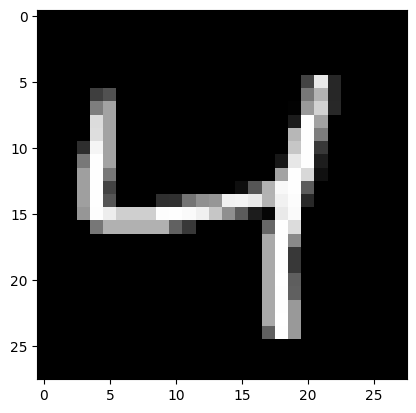

In [5]:
plt.imshow(X[2], cmap="gray")
plt.show()

### Çoklu Görüntülerin Görselleştirilmesi

Veri setinden ilk 9 örneği 3x3'lük bir grid üzerinde görselleştiririz. Her bir alt grafiğin başlığına, o görüntüye ait etiket yazdırılır. Bu, veri setindeki çeşitliliği ve etiketlerin doğruluğunu hızlıca kontrol etmek için yararlıdır.

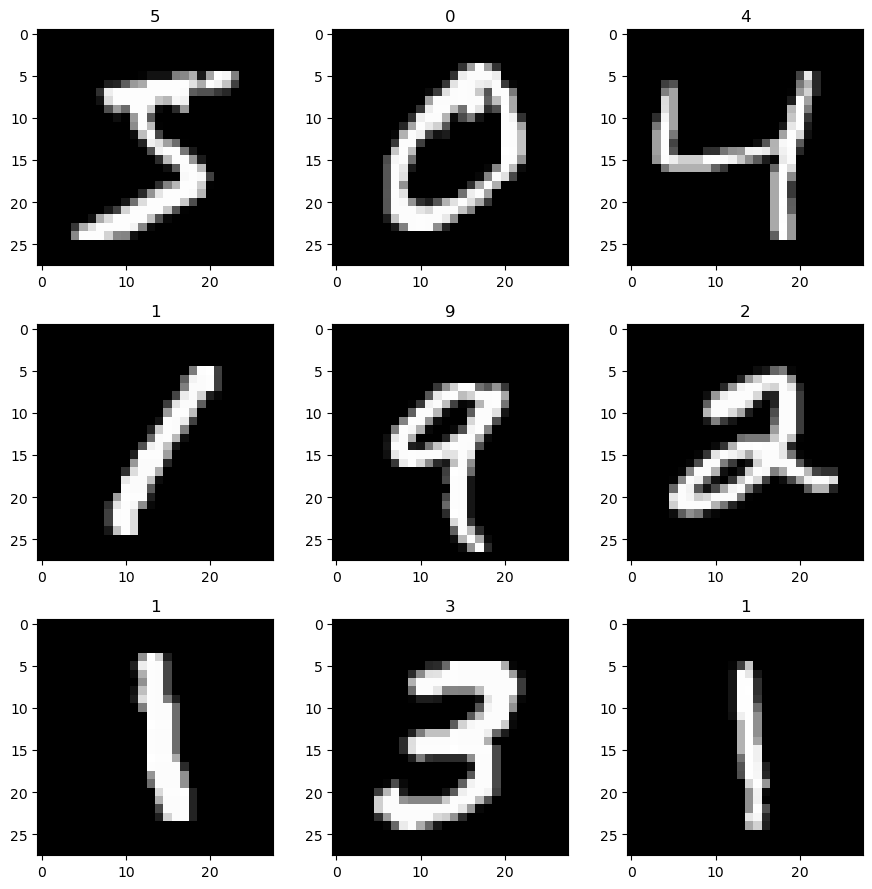

In [5]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.title(str(y[i]))
    plt.imshow(X[i], cmap="gray")

plt.tight_layout()
plt.show()

### NumPy ile Dizi İşlemleri: Fark Alma

İki NumPy dizisi arasındaki eleman bazında farkı gösteren basit bir örnek. Bu, KNN'de iki görüntü arasındaki piksel farklarını hesaplamanın temelini oluşturur.

In [6]:
a = np.array([[1, 3, 2],
              [1, 1, 2]])

b = np.array([[4, 1, 3],
              [2, 1, 2]])
print(a - b)

[[-3  2 -1]
 [-1  0  0]]


### L1 Uzaklığı (Manhattan Mesafesi) Hesabı - Örnek

L1 uzaklığı, iki dizi arasındaki farkların mutlak değerlerinin toplamıdır. Bu metrik, özellikle görüntüler arasındaki benzerlik veya farklılığı ölçmek için kullanılır. Manhattan mesafesi olarak da bilinir, çünkü bu mesafe, bir şehirdeki bloklar arasındaki mesafeyi ölçmek için kullanılan yönteme benzer.

#### Matematiksel Tanım

İki vektör \( a \) ve \( b \) arasındaki L1 uzaklığı şu şekilde hesaplanır:

\[
L1(a, b) = \sum_{i=1}^{n} |a_i - b_i|
\]

Burada:
- \( a \) ve \( b \), karşılaştırılan iki vektördür.
- \( n \), vektörlerin boyutudur.
- \( |a_i - b_i| \), her bir eleman arasındaki farkın mutlak değeridir.

#### Görüntüler İçin L1 Uzaklığı

Görüntüler, genellikle iki boyutlu matrisler olarak temsil edilir. Bu durumda, L1 uzaklığı, iki matris arasındaki tüm elemanların farklarının mutlak değerlerinin toplamı olarak hesaplanır:

\[
L1(A, B) = \sum_{i=1}^{h} \sum_{j=1}^{w} |A_{i,j} - B_{i,j}|
\]

Burada:
- \( A \) ve \( B \), karşılaştırılan iki görüntüdür.
- \( h \) ve \( w \), görüntülerin yüksekliği ve genişliğidir.
- \( A_{i,j} \) ve \( B_{i,j} \), görüntülerin \( (i, j) \) konumundaki piksel değerleridir.

#### Örnek Kullanım

L1 uzaklığı, el yazısı rakamların görüntülerini karşılaştırmak için kullanılabilir. Örneğin, MNIST veri setindeki iki görüntü arasındaki L1 uzaklığı, bu görüntülerin ne kadar benzer olduğunu ölçmek için kullanılabilir. Daha düşük bir L1 uzaklığı, görüntülerin daha benzer olduğunu gösterir.

Bu metrik, KNN algoritmasında sorgu görüntüsü ile eğitim setindeki görüntüler arasındaki uzaklıkları hesaplamak için yaygın olarak kullanılır.

In [7]:
np.sum(np.abs(a - b))

7

### Uzaklık Fonksiyonlarının Tanımlanması

KNN algoritmasında iki veri noktası (bu durumda iki görüntü) arasındaki benzerliği veya farklılığı ölçmek için uzaklık metrikleri kullanılır. Burada iki yaygın metrik tanımlanmıştır:

1.  **`l1_distance` (Manhattan Mesafesi):** İki görüntü arasındaki piksel farklarının mutlak değerlerinin toplamı. Şehir blokları arasındaki mesafe gibi düşünülebilir.
    $$ L1(a, b) = \sum_{i} |a_i - b_i| $$
2.  **`l2_distance` (Öklid Mesafesi):** İki görüntü arasındaki piksel farklarının karelerinin toplamının karekökü. İki nokta arasındaki düz çizgi mesafesidir.
    $$ L2(a, b) = \sqrt{\sum_{i} (a_i - b_i)^2} $$

Bu fonksiyonlar, daha sonra KNN sınıfında kullanılacaktır.

In [8]:
def l1_distance(img_a, img_b):
    fark = img_a - img_b
    mutlak = np.abs(fark)
    toplam_fark = np.sum(mutlak)
    return toplam_fark


def l2_distance(img_a, img_b):
    fark = img_a - img_b
    karesi = fark ** 2
    toplam = np.sum(karesi)
    karekok = np.sqrt(toplam)
    return karekok


a = np.array([[1, 1],
              [1, 1]])

b = np.array([[2, 2],
              [2, 2]])

dist = l1_distance(a, b)
print(dist)
dist = l2_distance(a, b)
print(dist)

4
2.0


### `collections.Counter` Kullanımı

`Counter`, bir listedeki elemanların kaç kez tekrar ettiğini sayar. `most_common()` metodu, en sık görünen elemanları ve frekanslarını bir liste olarak döndürür. `[0][0]` ifadesiyle en sık görünen elemanın kendisini alırız. Bu, KNN'de en yakın komşuların sınıfları arasında en popüler olanı bulmak için kullanılır.

In [9]:
c = Counter([2, 1, 2, 2, 1, 3])
c.most_common()[0][0]

2

### KNN için Sorgu Görüntüsü Seçimi

Sınıflandırmak istediğimiz bir görüntüyü (sorgu görüntüsü) veri setinden seçeriz. Bu örnekte 13. indeksteki görüntü seçilmiştir. Görüntüyü ve gerçek etiketini görselleştiririz.

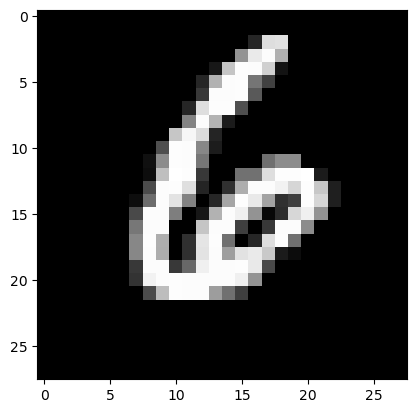

6


In [10]:
resim_idx = 13
query_img = X[resim_idx]
plt.imshow(query_img, cmap="gray")
plt.show()
print(y[resim_idx])

### Uzaklıkların Hesaplanması

Sorgu görüntüsünün, eğitim setindeki (`X`) **her bir** görüntüye olan uzaklığını (bu örnekte L1 uzaklığı kullanılarak) hesaplarız ve sonuçları `uzakliklar` listesinde saklarız. Bu, KNN'nin en hesaplama yoğun adımıdır, çünkü sorgu görüntüsünü tüm eğitim verisiyle karşılaştırmayı gerektirir.

In [11]:
uzakliklar = []
for img in X:
    uzaklik = l1_distance(img, query_img)
    uzakliklar.append(uzaklik)

print(uzakliklar[:10])

[29034, 31068, 27608, 25556, 26515, 29830, 22483, 36096, 19551, 26997]


### `np.argsort` Kullanımı

`np.argsort`, bir dizinin elemanlarını küçükten büyüğe sıraladığımızda orijinal indekslerin nasıl bir sırada olacağını döndürür. Örneğin, `[3, 1, -1, 7, 2]` dizisi sıralandığında `[-1, 1, 2, 3, 7]` olur. Bu sıralanmış dizideki elemanların orijinal dizideki indeksleri `[2, 1, 4, 0, 3]`'tür. KNN'de, hesaplanan uzaklıkları sıralayarak en yakın komşuların indekslerini bulmak için kullanılır.

In [12]:
np.argsort([3, 1, -1, 7, 2])

array([2, 1, 4, 0, 3])

### En Yakın Komşuların Bulunması

1.  `np.argsort(uzakliklar)` ile uzaklıkları küçükten büyüğe sıralayan indeksleri buluruz.
2.  `K` değerini belirleriz (örneğin K=3). Bu, kaç tane en yakın komşuya bakacağımızı belirler.
3.  Sıralı indekslerin `[1:K+1]` aralığını alırız. Neden 1'den başlıyoruz? Çünkü 0. indeks her zaman sorgu görüntüsünün kendisine olan uzaklığı (yani 0) temsil eder. Biz kendisi dışındaki en yakın `K` komşuyu istiyoruz.

Sonuç olarak `en_yakin_komsular`, sorgu görüntüsüne en yakın `K` adet görüntünün eğitim setindeki (`X`) indekslerini içerir.

In [13]:
sirali_indeksler = np.argsort(uzakliklar)
en_yakin_komsular = sirali_indeksler[1:4]

### En Yakın Komşuların Görselleştirilmesi

Bulduğumuz en yakın komşulardan birini (örneğin 3. en yakın komşuyu) ve etiketini görselleştiririz. Bu, algoritmanın mantıksal olarak benzer görüntüleri bulup bulmadığını kontrol etmeye yardımcı olur.

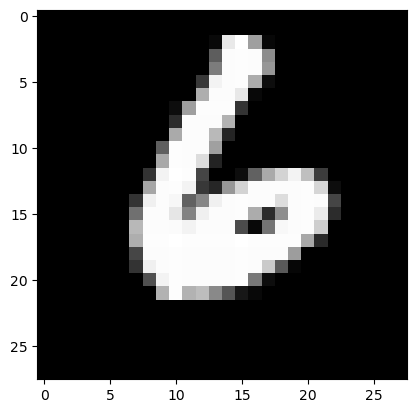

6


In [14]:
resim_idx = 13
plt.imshow(X[en_yakin_komsular[2]], cmap="gray")
plt.show()
print(y[en_yakin_komsular[2]])

### Komşu Sınıflarının Belirlenmesi

En yakın `K` komşunun indekslerini kullanarak, bu komşuların gerçek etiketlerini (`y` dizisinden) alırız ve `komsu_siniflari` listesinde toplarız.

In [15]:
komsu_siniflari = []
for komsu in en_yakin_komsular:
    komsu_siniflari.append(y[komsu])

### Tahmin Yapma (Sınıf Belirleme)

`Counter(komsu_siniflari)` ile en yakın komşuların sınıflarının frekanslarını sayarız. `most_common()[0][0]` ifadesiyle bu sınıflar arasında en sık görüneni (yani çoğunluk oyunu alanı) buluruz. Bu, KNN algoritmasının sorgu görüntüsü için yaptığı tahmindir.

In [ ]:
Counter(komsu_siniflari).most_common()[0][0]

### KNN Sınıfının Oluşturulması

Yukarıdaki adımları (uzaklık hesaplama, sıralama, en yakınları bulma, sınıf belirleme) daha yapılandırılmış ve yeniden kullanılabilir hale getirmek için bir Python sınıfı (`KNN`) oluşturuyoruz.

- **`__init__(self, distance_fun, K)`:** Sınıfın yapıcı metodu. Kullanılacak uzaklık fonksiyonunu (`distance_fun`, örn. `l1_distance` veya `l2_distance`) ve komşu sayısı `K`'yı parametre olarak alır ve sınıfın özelliklerinde saklar.
- **`fit(self, X, y)`:** Eğitim verisini (`X`) ve etiketlerini (`y`) alır ve sınıfın özelliklerinde saklar. KNN'de 
 aslında sadece veriyi ezberlemektir, karmaşık bir model oluşturma süreci yoktur.
- **`predict(self, query_img)`:** Yeni bir sorgu görüntüsü (`query_img`) alır. Bu metot, daha önce manuel olarak yaptığımız adımları uygular:
    1. Sorgu görüntüsünün tüm eğitim görüntülerine olan uzaklıklarını hesaplar.
    2. Uzaklıkları sıralar.
    3. En yakın `K` komşunun indekslerini bulur (kendisi hariç).
    4. Bu komşuların sınıflarını alır.
    5. En sık görünen sınıfı (tahmini) döndürür.

In [ ]:
class KNN:
    def __init__(self, distance_fun, K):
        self.distance_fun = distance_fun
        self.K = K

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict(self, query_img):
        uzakliklar = []
        for img in self.X:
            uzaklik = self.distance_fun(img, query_img)
            uzakliklar.append(uzaklik)
        sirali_indeksler = np.argsort(uzakliklar)
        en_yakin_komsular = sirali_indeksler[1:self.K+1]
        komsu_siniflari = []
        for komsu in en_yakin_komsular:
            komsu_siniflari.append(y[komsu])

        return Counter(komsu_siniflari).most_common()[0][0]

### KNN Sınıfının Kullanımı ve Test Edilmesi

1.  `KNN` sınıfından bir nesne (`knn`) oluştururuz. Örnek olarak L2 uzaklık fonksiyonunu (`l2_distance`) ve `K=7` değerini kullanıyoruz.
2.  `knn.fit(X, y)` ile modeli (yani veriyi) eğitiyoruz.
3.  Test etmek için bir sorgu görüntüsü seçiyoruz (örneğin 0. indeksteki görüntü).
4.  `knn.predict(query_img)` ile seçilen görüntü için sınıf tahminini yapıyoruz.
5.  Tahmin sonucunu ve orijinal görüntüyü yazdırarak sonucu kontrol ediyoruz.

In [ ]:
resim_idx = 0
knn = KNN(l2_distance, 7)
knn.fit(X, y)
query_img = X[resim_idx]
sonuc = knn.predict(query_img)
print(sonuc)
plt.imshow(X[resim_idx], cmap="gray")
plt.show()

### Farklı Parametrelerle KNN Testi

Bu hücrede, farklı bir sorgu görüntüsü ve farklı parametrelerle KNN algoritmasını test ederiz. Örneğin, L1 uzaklık fonksiyonunu ve `K=5` değerini kullanarak tahmin yaparız.